# 시계열 데이터 예시

In [50]:
# ============================================
# 주가 시계열 데이터 확장 + RNN 학습용 데이터 생성
# ============================================
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------
# 1. 주가 시계열 데이터 생성 (120일치)
# --------------------------------------------
np.random.seed(42)
days = 120  # 약 6개월 (거래일 기준)

# 시작 가격
start_price = 50000

# 주가 = 상승 추세 + 사인 주기 패턴 + 랜덤 노이즈
timesteps = np.arange(days)
trend = timesteps * 50                          # 하루 평균 50원씩 상승 추세
cycle = 3000 * np.sin(timesteps * 0.1)          # 주기적 등락 (사인 패턴)
noise = np.random.randn(days) * 500             # 랜덤 변동성

stock_prices = start_price + trend + cycle + noise

# 전일 대비 변화량
changes = np.diff(stock_prices, prepend=stock_prices[0])




In [51]:
# --------------------------------------------
# 2. 데이터 확인 (처음 10일)
# --------------------------------------------
print("=" * 55)
print("주가 시퀀스 (처음 10일)")
print("=" * 55)
for i in range(10):
    price = stock_prices[i]
    change = changes[i]
    sign = "+" if change >= 0 else ""
    arrow = "↑" if change > 0 else ("↓" if change < 0 else " ")
    print(f"  Day {i+1:3d}: {price:,.0f}원 {arrow} ({sign}{change:,.0f})")
print(f"  ... (총 {days}일)")
print()



주가 시퀀스 (처음 10일)
  Day   1: 50,248원   (+0)
  Day   2: 50,280원 ↑ (+32)
  Day   3: 51,020원 ↑ (+739)
  Day   4: 51,798원 ↑ (+778)
  Day   5: 51,251원 ↓ (-547)
  Day   6: 51,571원 ↑ (+320)
  Day   7: 52,784원 ↑ (+1,212)
  Day   8: 52,666원 ↓ (-117)
  Day   9: 52,317원 ↓ (-349)
  Day  10: 53,071원 ↑ (+754)
  ... (총 120일)



# 시계열 데이터 시각화

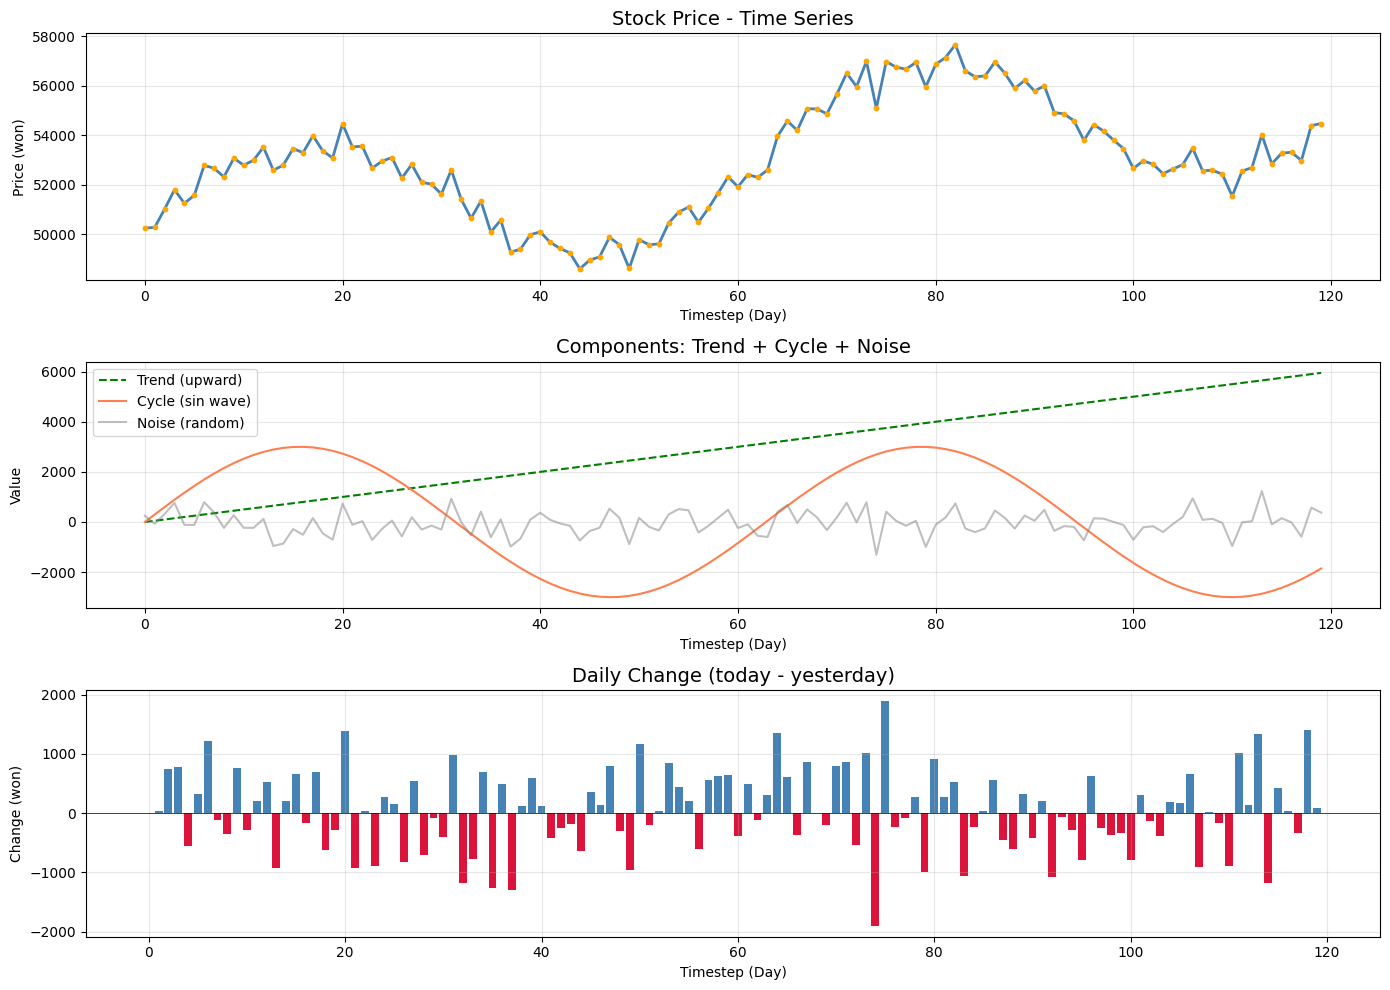

In [52]:
# --------------------------------------------
# 3. 시각화
# --------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# 3-1) 주가 흐름
axes[0].plot(timesteps, stock_prices, color='steelblue', linewidth=2)
axes[0].scatter(timesteps, stock_prices, color='orange', s=10, zorder=5)
axes[0].set_title("Stock Price - Time Series", fontsize=14)
axes[0].set_xlabel("Timestep (Day)")
axes[0].set_ylabel("Price (won)")
axes[0].grid(True, alpha=0.3)

# 3-2) 주가 구성 요소 분해
axes[1].plot(timesteps, trend, label='Trend (upward)', linestyle='--', color='green')
axes[1].plot(timesteps, cycle, label='Cycle (sin wave)', linestyle='-', color='coral')
axes[1].plot(timesteps, noise, label='Noise (random)', linestyle='-', color='gray', alpha=0.5)
axes[1].set_title("Components: Trend + Cycle + Noise", fontsize=14)
axes[1].set_xlabel("Timestep (Day)")
axes[1].set_ylabel("Value")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# 3-3) 전일 대비 변화량
colors = ['crimson' if c < 0 else 'steelblue' for c in changes]
axes[2].bar(timesteps, changes, color=colors, width=0.8)
axes[2].axhline(y=0, color='black', linewidth=0.5)
axes[2].set_title("Daily Change (today - yesterday)", fontsize=14)
axes[2].set_xlabel("Timestep (Day)")
axes[2].set_ylabel("Change (won)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



# 4. RNN 학습용 데이터 구조 미리보기

In [53]:
# --------------------------------------------
# 4. RNN 학습용 데이터 구조 미리보기
# --------------------------------------------
print("=" * 55)
print("RNN 학습용 데이터 구조 (window_size=5)")
print("=" * 55)
window_size = 5
print(f"  입력(X): 과거 {window_size}일 주가 → 출력(y): 다음 1일 주가")
print()
for i in range(3):
    x = stock_prices[i:i+window_size]
    y = stock_prices[i+window_size]
    x_str = [f"{v:,.0f}" for v in x]
    print(f"  샘플 {i+1}: X={x_str} → y={y:,.0f}")
print(f"  ...")
print(f"  총 샘플 수: {days - window_size}개")
print()
print("→ RNN은 과거 5일 패턴을 보고 내일 주가를 예측!")

RNN 학습용 데이터 구조 (window_size=5)
  입력(X): 과거 5일 주가 → 출력(y): 다음 1일 주가

  샘플 1: X=['50,248', '50,280', '51,020', '51,798', '51,251'] → y=51,571
  샘플 2: X=['50,280', '51,020', '51,798', '51,251', '51,571'] → y=52,784
  샘플 3: X=['51,020', '51,798', '51,251', '51,571', '52,784'] → y=52,666
  ...
  총 샘플 수: 115개

→ RNN은 과거 5일 패턴을 보고 내일 주가를 예측!


# imdb 영화 평론

In [54]:
import tensorflow
from tensorflow.keras.datasets import imdb
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25000,), (25000,), (25000,), (25000,))

In [ ]:
X_train[0]

In [55]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_train_pad= pad_sequences(X_train, maxlen=80, truncating='post', padding='post')
X_test_pad= pad_sequences(X_test, maxlen=80, truncating='post', padding='post') 

# DNN
embedding 층
dense 층 - 은닉
dense 층 - 출력

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, Flatten

model = Sequential()

# Embedding: 단어 인덱스 → 의미 벡터로 변환
model.add(Embedding(input_dim=10000, output_dim=32, input_length=80))
model.add(Flatten())

# 은닉층
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# 출력층
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


/home/ubuntu/miniforge3/envs/dl_env/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# DNN 모델 학습

In [57]:
# ============================================
# 모델 컴파일 + 학습
# ============================================
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train_pad, y_train,
                    epochs=10,
                    batch_size=256,
                    validation_split=0.2)


Epoch 1/10


I0000 00:00:1775021426.166716   20886 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_74654__.13


72/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5257 - loss: 0.6890

I0000 00:00:1775021427.695770   20885 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_74654__.13


79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5863 - loss: 0.6639 - val_accuracy: 0.7594 - val_loss: 0.5048
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8292 - loss: 0.3884 - val_accuracy: 0.8006 - val_loss: 0.4293
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9464 - loss: 0.1591 - val_accuracy: 0.7810 - val_loss: 0.5651
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9917 - loss: 0.0355 - val_accuracy: 0.7812 - val_loss: 0.8191
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9986 - loss: 0.0077 - val_accuracy: 0.7772 - val_loss: 0.9772
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9992 - loss: 0.0036 - val_accuracy: 0.7778 - val_loss: 1.0718
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9997 - loss: 0.0019 - val_accuracy: 0.7814 - val_loss: 1.1382
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9996 - loss: 0.0021 - val_accuracy: 0.7784 - val_loss: 1.1805
Ep

# DNN 테스트 평가

In [58]:
# ============================================
# 테스트 평가
# ============================================
test_loss, test_acc = model.evaluate(X_test_pad, y_test)
print(f"테스트 정확도: {test_acc:.4f}")
print(f"테스트 손실  : {test_loss:.4f}")


782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7650 - loss: 1.4096
테스트 정확도: 0.7650
테스트 손실  : 1.4096


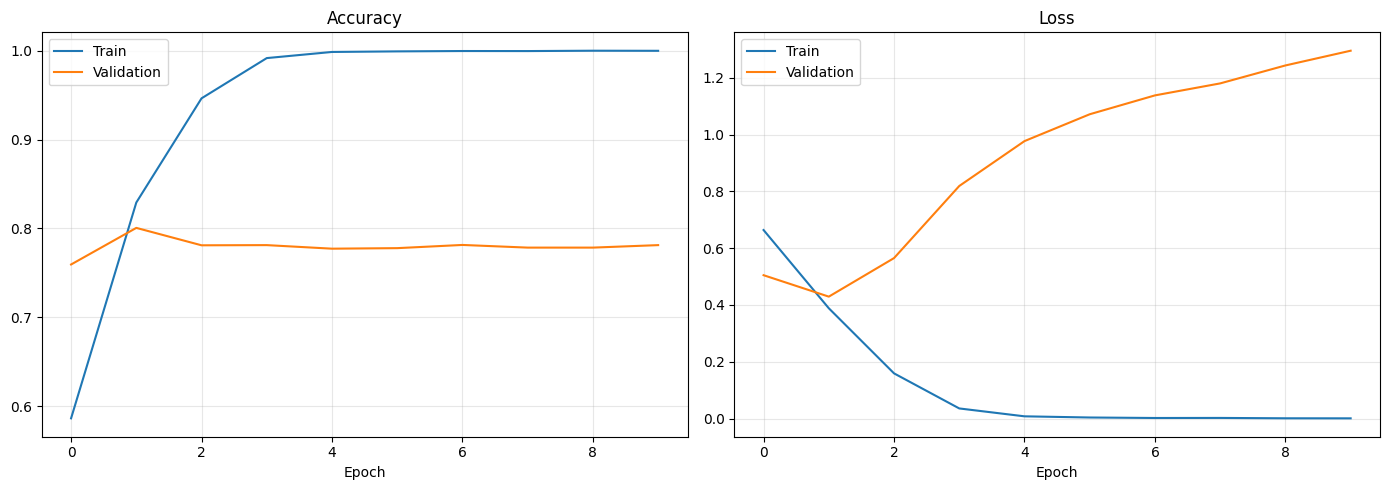

In [59]:
# ============================================
# 학습 과정 시각화
# ============================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 정확도
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 손실
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# 학습 과정 시각화

# RNN

In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense

model = Sequential([
    Input(shape=(80,)),
    Embedding(input_dim=10000, output_dim=32),
    SimpleRNN(64),
    Dense(2, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 80, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326,338 (1.24 MB)

 Trainable params: 326,338 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

# 패딩 처리

In [61]:
# 패딩 처리
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_train_pad = pad_sequences(X_train, maxlen=80, truncating='post', padding='post')
X_test_pad = pad_sequences(X_test, maxlen=80, truncating='post', padding='post')


# 모델 학습

In [62]:
%%time
history = model.fit(X_train_pad, y_train, epochs=10, batch_size=200, validation_split=0.2)


Epoch 1/10


I0000 00:00:1775021456.727457   20885 dot_merger.cc:481] Merging Dots in computation: sequential_7_1_simple_rnn_2_1_while_body_83561_grad_83715_const_0__.21.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1775021456.727578   20885 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_84160__.24


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5419 - loss: 0.6883 - val_accuracy: 0.5098 - val_loss: 0.6931
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6510 - loss: 0.6392 - val_accuracy: 0.6780 - val_loss: 0.5918
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8352 - loss: 0.3804 - val_accuracy: 0.7872 - val_loss: 0.4636
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9277 - loss: 0.1936 - val_accuracy: 0.7606 - val_loss: 0.5618
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9774 - loss: 0.0805 - val_accuracy: 0.7868 - val_loss: 0.6381
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9923 - loss: 0.0327 - val_accuracy: 0.7582 - val_loss: 0.7097
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9974 - loss: 0.0153 - val_accuracy: 0.7710 - val_loss: 0.8242
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9990 - loss: 0.0079 - val_accuracy: 0.773

# 테스트 평가

In [63]:
# 테스트 평가
test_loss, test_acc = model.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss    : {test_loss:.4f}")


782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7490 - loss: 0.9955
Test Accuracy: 0.7490
Test Loss    : 0.9955


# 학습 과정 시각화

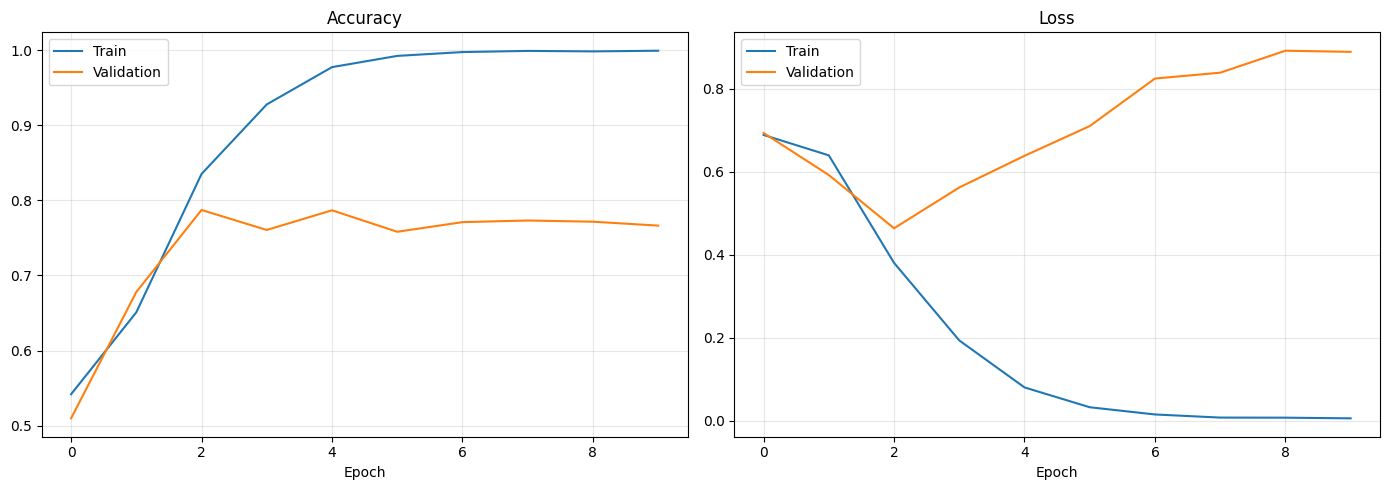

In [64]:
# 학습 과정 시각화
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 정확도
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 손실
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# SimpleRNN Train/Val Acc 저장 (결과 요약표용)
rnn_train_acc = round(history.history['accuracy'][-1], 4)
rnn_val_acc = round(history.history['val_accuracy'][-1], 4)

# 1 LSTM 모델

In [65]:
# ============================================
# LSTM 모델 (IMDB 긍정/부정 분류)
# ============================================
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

# 데이터 로드
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

# 패딩 처리 (pre 방식 적용)
X_train_pad = pad_sequences(X_train, maxlen=80, truncating='pre', padding='pre')
X_test_pad = pad_sequences(X_test, maxlen=80, truncating='pre', padding='pre')


# 2 모델 구성

In [66]:
# 모델 구성
model = Sequential([
    Input(shape=(80,)),
    Embedding(input_dim=10000, output_dim=32),
    LSTM(64),
    Dense(2, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 80, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 344,962 (1.32 MB)

 Trainable params: 344,962 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

# 3 모델 학습

In [67]:
%%time
history = model.fit(X_train_pad, y_train, epochs=10, batch_size=200, validation_split=0.2)


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7390 - loss: 0.5071 - val_accuracy: 0.8224 - val_loss: 0.3841
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8726 - loss: 0.3028 - val_accuracy: 0.8370 - val_loss: 0.3637
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9085 - loss: 0.2359 - val_accuracy: 0.8342 - val_loss: 0.4013
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9275 - loss: 0.1975 - val_accuracy: 0.8278 - val_loss: 0.4098
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9428 - loss: 0.1559 - val_accuracy: 0.8196 - val_loss: 0.4861
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9546 - loss: 0.1253 - val_accuracy: 0.8160 - val_loss: 0.5441
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9675 - loss: 0.0967 - val_accuracy: 0.8140 - val_loss: 0.6432
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9737 - loss: 0.0779 - val_accura

# 4 테스트 평가

In [68]:
# 테스트 평가
test_loss, test_acc = model.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss    : {test_loss:.4f}")


782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8065 - loss: 0.6890
Test Accuracy: 0.8065
Test Loss    : 0.6890


# 5 학습 과정 시각화

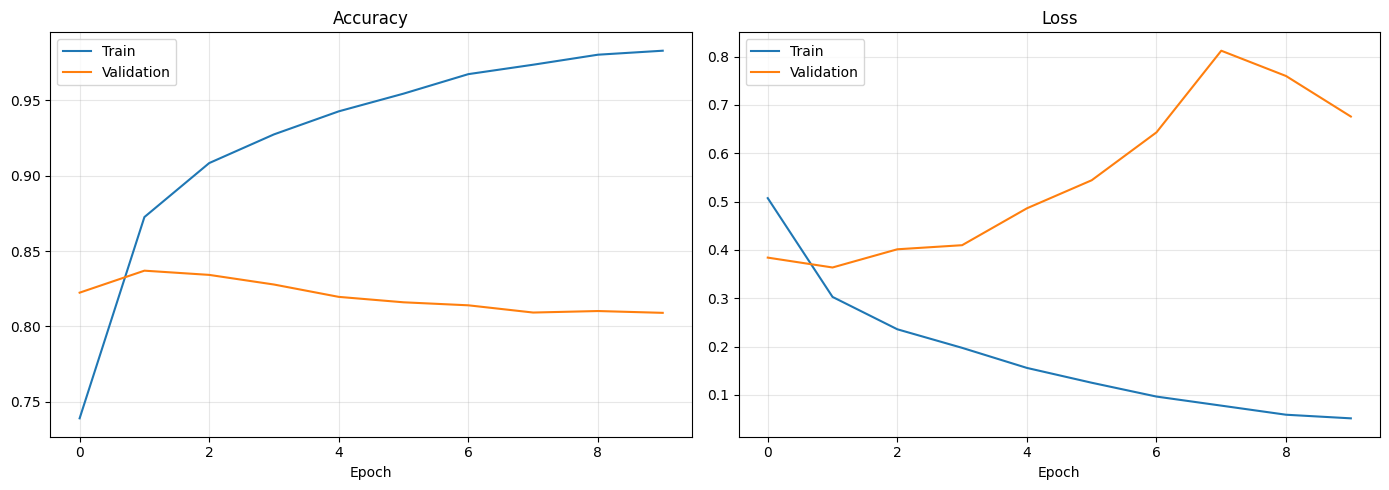

In [69]:
# 학습 과정 시각화
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 정확도
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 손실
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 전체 실험 결과 요약

In [70]:
# ============================================
# 전체 실험 결과 요약
# ============================================
import pandas as pd

# LSTM history에서 Train Acc, Val Acc 가져오기
lstm_train_acc = round(history.history['accuracy'][-1], 4)
lstm_val_acc = round(history.history['val_accuracy'][-1], 4)
lstm_test_acc = 0.8000

results = {
    '실험': ['Step 1', 'Step 2', 'Step 3', 'Step 4'],
    '모델 구조': ['DNN', 'DNN + Embedding', 'SimpleRNN + Embedding', 'LSTM'],
    'Train Acc': [0.5100, 1.0000, rnn_train_acc, lstm_train_acc],
    'Val Acc': [0.5000, 0.7800, rnn_val_acc, lstm_val_acc],
    'Test Acc': [0.5000, 0.7800, 0.7482, lstm_test_acc],
    '특이사항': [
        '학습 실패, 랜덤 수준(50%)',
        '극단적 과적합, val_loss 상승',
        '훈련 100% 수렴, 테스트 급락',
        'padding=pre 적용, 성능 향상'
    ]
}

df = pd.DataFrame(results)
df = df.set_index('실험')
df

,모델 구조,Train Acc,Val Acc,Test Acc,특이사항
실험,,,,,
Step 1,DNN,0.5100,0.5000,0.5000,"학습 실패, 랜덤 수준(50%)"
Step 2,DNN + Embedding,1.0000,0.7800,0.7800,"극단적 과적합, val_loss 상승"
Step 3,SimpleRNN + Embedding,0.9992,0.7664,0.7482,"훈련 100% 수렴, 테스트 급락"
Step 4,LSTM,0.9830,0.8090,0.8000,"padding=pre 적용, 성능 향상"


# California Housing
캘리포니아 지역의 주택 정보(소득, 위치, 방 수 등)를 보고 집값을 예측하는 AI 모델을 만듭니다.
"1990년 기준으로 소득이 X이고, 위치가 Y이면 집값은 얼마일까?"만 예측할 수 있습니다.

데이터 시점: 	1990년 미국 인구조사
지역 범위:  	Berkeley만이 아닌 캘리포니아 주 전체
데이터 수:  	20,640개 (캘리포니아 전체 블록 그룹)

같은 데이터에 6가지 신경망 모델을 적용했을 때 어떤 모델이 가장 정확한지 비교하는 것이 핵심 목표입니다.

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target          # 단위: $100,000

print(df.shape)                    # (20640, 9)
print(df.describe())

(20640, 9)
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         Price  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308  

In [ ]:
df.head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


In [73]:
# ============================================
# California Housing - 데이터 준비 (공통)
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 데이터 로드
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target  # 단위: $100,000

# X, y 분리
X = df.drop('Price', axis=1).values
y = df['Price'].values

# 학습/테스트 분리 (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 스케일링 (표준화)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train: {X_train_scaled.shape}")
print(f"X_test : {X_test_scaled.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")


X_train: (16512, 8)
X_test : (4128, 8)
y_train: (16512,)
y_test : (4128,)


# Step 1. 기본 DNN 회귀 모델

In [74]:
# ============================================
# Step 1. 기본 DNN 회귀 모델
# ============================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_dnn = Sequential([
    Dense(128, activation='relu', input_shape=(8,)),
    Dense(64, activation='relu'),
    Dense(1)  # 회귀: 활성화 함수 없음
])

model_dnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_dnn.summary()


/home/ubuntu/miniforge3/envs/dl_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,473 (37.00 KB)

 Trainable params: 9,473 (37.00 KB)

 Non-trainable params: 0 (0.00 B)

# Step 1. 기본 DNN - 학습

In [75]:
# ============================================
# Step 1. 기본 DNN - 학습
# ============================================
history_dnn = model_dnn.fit(X_train_scaled, y_train,
                            epochs=50,
                            batch_size=128,
                            validation_split=0.2,
                            verbose=1)


Epoch 1/50


I0000 00:00:1775024517.455081   20884 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_105168__.9
I0000 00:00:1775024517.681642   20884 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775024518.300719   20884 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775024518.582045   66441 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_20', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1775024518.648036   20884 dot_search_space.cc:240] All configs were filtered out because none

 95/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.6634 - mae: 1.2368

I0000 00:00:1775024520.218875   20889 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_105168__.9


104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.5585 - mae: 1.2032

I0000 00:00:1775024521.793737   20885 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775024522.016577   66635 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 8 bytes spill stores, 8 bytes spill loads



104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 1.4258 - mae: 0.8409 - val_loss: 0.6452 - val_mae: 0.5654
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5035 - mae: 0.5043 - val_loss: 0.4610 - val_mae: 0.4856
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4063 - mae: 0.4537 - val_loss: 0.4188 - val_mae: 0.4568
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3816 - mae: 0.4376 - val_loss: 0.4065 - val_mae: 0.4447
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3649 - mae: 0.4289 - val_loss: 0.3967 - val_mae: 0.4373
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3607 - mae: 0.4242 - val_loss: 0.3829 - val_mae: 0.4388
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3480 - mae: 0.4179 - val_loss: 0.3776 - val_mae: 0.4264
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3413 - mae: 0.4131 - val_loss: 0.3734 - val_mae: 0.4258
Epoch 9/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3367

# Step 1. 기본 DNN - 테스트 평가

In [76]:
# ============================================
# Step 1. 기본 DNN - 테스트 평가
# ============================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_dnn = model_dnn.predict(X_test_scaled).flatten()

mse_dnn = mean_squared_error(y_test, y_pred_dnn)
mae_dnn = mean_absolute_error(y_test, y_pred_dnn)
r2_dnn = r2_score(y_test, y_pred_dnn)

print(f"[Step 1] 기본 DNN 결과")
print(f"  MSE    : {mse_dnn:.4f}")
print(f"  MAE    : {mae_dnn:.4f}")
print(f"  R² Score: {r2_dnn:.4f}")


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[Step 1] 기본 DNN 결과
  MSE    : 0.2821
  MAE    : 0.3590
  R² Score: 0.7847


# Step 1. 기본 DNN - 학습 과정 시각화

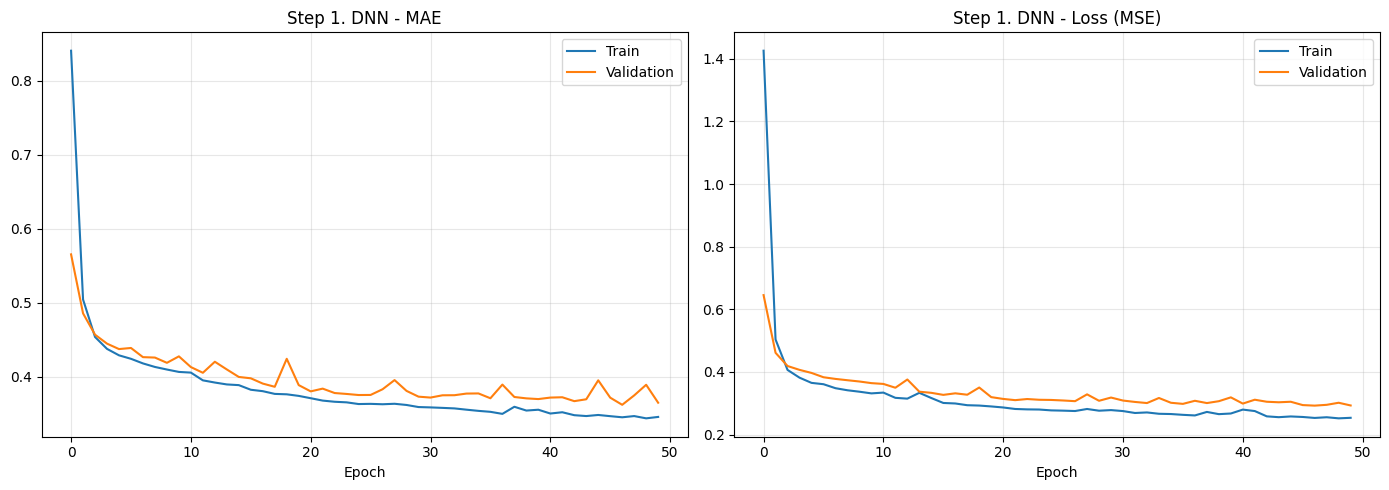

In [77]:
# ============================================
# Step 1. 기본 DNN - 학습 과정 시각화
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_dnn.history['mae'], label='Train')
axes[0].plot(history_dnn.history['val_mae'], label='Validation')
axes[0].set_title('Step 1. DNN - MAE')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_dnn.history['loss'], label='Train')
axes[1].plot(history_dnn.history['val_loss'], label='Validation')
axes[1].set_title('Step 1. DNN - Loss (MSE)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Step 2 Deep DNN 모델 구성

In [78]:
# ============================================
# Step 2. Deep DNN 모델 구성
# ============================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

model_deep = Sequential([
    Dense(256, activation='relu', input_shape=(8,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model_deep.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_deep.summary()


/home/ubuntu/miniforge3/envs/dl_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,105 (184.00 KB)

 Trainable params: 46,337 (181.00 KB)

 Non-trainable params: 768 (3.00 KB)

# Step 2 Deep DNN - 학습

In [79]:
# ============================================
# Step 2. Deep DNN - 학습
# ============================================
history_deep = model_deep.fit(X_train_scaled, y_train,
                              epochs=50,
                              batch_size=128,
                              validation_split=0.2,
                              verbose=1)


Epoch 1/50


I0000 00:00:1775024674.348773   20884 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_136600__.26
I0000 00:00:1775024674.402425   20884 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775024674.678870   70705 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_8', 32 bytes spill stores, 32 bytes spill loads

I0000 00:00:1775024674.768695   20884 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775024675.029690   70717 subprocess_compilation.cc:348] ptxas warning : Registers are spil

 98/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.9984 - mae: 1.0389

I0000 00:00:1775024679.305599   20884 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_136600__.26


104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 1.9529 - mae: 1.0253

I0000 00:00:1775024685.968112   20887 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


104/104 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - loss: 1.2026 - mae: 0.7992 - val_loss: 2.2448 - val_mae: 1.1178
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6763 - mae: 0.6084 - val_loss: 1.2570 - val_mae: 0.7708
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5845 - mae: 0.5579 - val_loss: 0.8672 - val_mae: 0.6315
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5190 - mae: 0.5264 - val_loss: 0.7993 - val_mae: 0.5965
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4842 - mae: 0.5083 - val_loss: 0.8784 - val_mae: 0.6598
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4675 - mae: 0.4931 - val_loss: 0.7174 - val_mae: 0.5896
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4456 - mae: 0.4835 - val_loss: 0.6216 - val_mae: 0.5478
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4263 - mae: 0.4689 - val_loss: 0.4884 - val_mae: 0.4684
Epoch 9/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.418

# Step 2 Deep DNN - 테스트 평가

In [80]:
# ============================================
# Step 2. Deep DNN - 테스트 평가
# ============================================
y_pred_deep = model_deep.predict(X_test_scaled).flatten()

mse_deep = mean_squared_error(y_test, y_pred_deep)
mae_deep = mean_absolute_error(y_test, y_pred_deep)
r2_deep = r2_score(y_test, y_pred_deep)

print(f"[Step 2] Deep DNN 결과")
print(f"  MSE    : {mse_deep:.4f}")
print(f"  MAE    : {mae_deep:.4f}")
print(f"  R² Score: {r2_deep:.4f}")


129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[Step 2] Deep DNN 결과
  MSE    : 0.3307
  MAE    : 0.3845
  R² Score: 0.7476


# Step 2 Deep DNN - 학습 과정 시각화

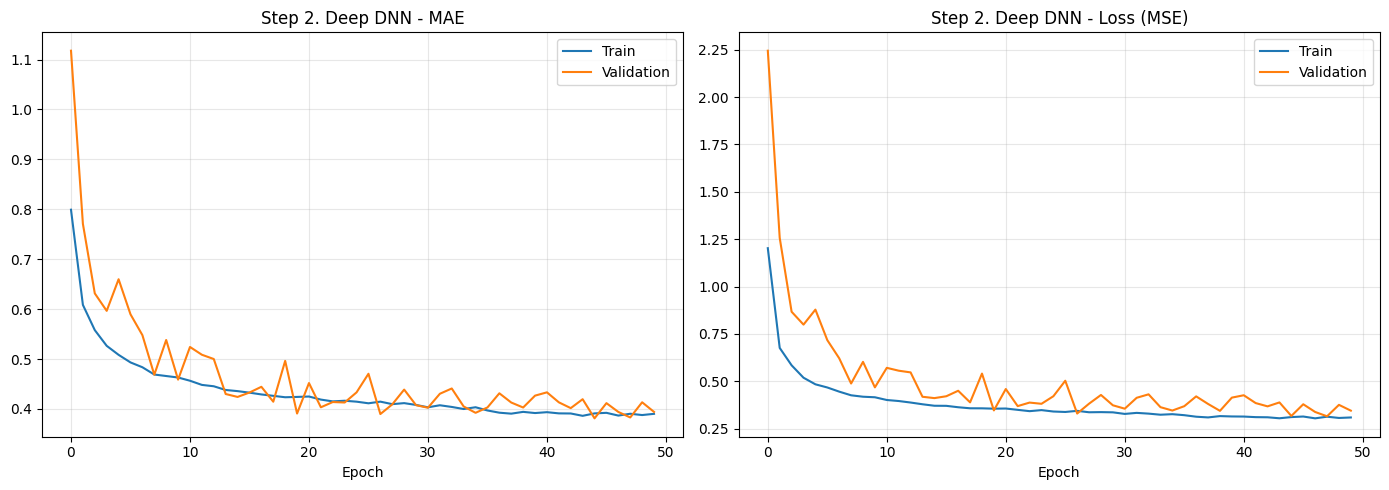

In [81]:
# ============================================
# Step 2. Deep DNN - 학습 과정 시각화
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_deep.history['mae'], label='Train')
axes[0].plot(history_deep.history['val_mae'], label='Validation')
axes[0].set_title('Step 2. Deep DNN - MAE')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_deep.history['loss'], label='Train')
axes[1].plot(history_deep.history['val_loss'], label='Validation')
axes[1].set_title('Step 2. Deep DNN - Loss (MSE)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Step 3 데이터 reshape (8개 특성 → 8 타임스텝 × 1)

In [82]:
# ============================================
# Step 3. 데이터 reshape (8개 특성 → 8 타임스텝 × 1)
# ============================================
X_train_rnn = X_train_scaled.reshape(-1, 8, 1)
X_test_rnn = X_test_scaled.reshape(-1, 8, 1)

print(f"RNN 입력 shape: {X_train_rnn.shape}")
# (16512, 8, 1) → 8 타임스텝, 1 특성


RNN 입력 shape: (16512, 8, 1)


# Step 3 SimpleRNN 모델 구성

In [83]:
# ============================================
# Step 3. SimpleRNN 모델 구성
# ============================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input

model_rnn = Sequential([
    Input(shape=(8, 1)),
    SimpleRNN(64),
    Dense(32, activation='relu'),
    Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_rnn.summary()


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

# Step 3 SimpleRNN - 학습

In [84]:
# ============================================
# Step 3. SimpleRNN - 학습
# ============================================
history_rnn = model_rnn.fit(X_train_rnn, y_train,
                            epochs=50,
                            batch_size=128,
                            validation_split=0.2,
                            verbose=1)


Epoch 1/50


I0000 00:00:1775024948.502645   20879 dot_merger.cc:481] Merging Dots in computation: sequential_11_1_simple_rnn_3_1_while_body_166567_grad_166770_const_0__.18.clone.clone.clone.clone.clone
I0000 00:00:1775024948.502724   20879 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_167239__.19
I0000 00:00:1775024948.513319   20879 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775024948.800101   75369 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_26', 32 bytes spill stores, 32 bytes spill loads

I0000 00:00:1775024948.898061   20879 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good repres

 97/104 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.9778 - mae: 1.0399

I0000 00:00:1775024951.434296   20879 dot_merger.cc:481] Merging Dots in computation: sequential_11_1_simple_rnn_3_1_while_body_166567_grad_166770_const_0__.18.clone.clone.clone.clone.clone
I0000 00:00:1775024951.434371   20879 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_167239__.19
I0000 00:00:1775024951.442832   20879 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775024951.726642   75456 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_7', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1775024951.802306   20879 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good represent

104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.9159 - mae: 1.0199

I0000 00:00:1775024953.496669   20879 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 1.0468 - mae: 0.7377 - val_loss: 0.5362 - val_mae: 0.5386
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4662 - mae: 0.4966 - val_loss: 0.4804 - val_mae: 0.5202
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4337 - mae: 0.4750 - val_loss: 0.4560 - val_mae: 0.4879
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4138 - mae: 0.4609 - val_loss: 0.4549 - val_mae: 0.4934
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.4105 - mae: 0.4594 - val_loss: 0.4539 - val_mae: 0.4905
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3992 - mae: 0.4502 - val_loss: 0.4146 - val_mae: 0.4577
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3870 - mae: 0.4423 - val_loss: 0.4100 - val_mae: 0.4465
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3886 - mae: 0.4432 - val_loss: 0.4083 - val_mae: 0.4389
Epoch 9/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3767

# Step 3 SimpleRNN - 테스트 평가

In [85]:
# ============================================
# Step 3. SimpleRNN - 테스트 평가
# ============================================
y_pred_rnn = model_rnn.predict(X_test_rnn).flatten()

mse_rnn = mean_squared_error(y_test, y_pred_rnn)
mae_rnn = mean_absolute_error(y_test, y_pred_rnn)
r2_rnn = r2_score(y_test, y_pred_rnn)

print(f"[Step 3] SimpleRNN 결과")
print(f"  MSE    : {mse_rnn:.4f}")
print(f"  MAE    : {mae_rnn:.4f}")
print(f"  R² Score: {r2_rnn:.4f}")


129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[Step 3] SimpleRNN 결과
  MSE    : 0.3259
  MAE    : 0.4064
  R² Score: 0.7513


# Step 3 SimpleRNN - 학습 과정 시각화

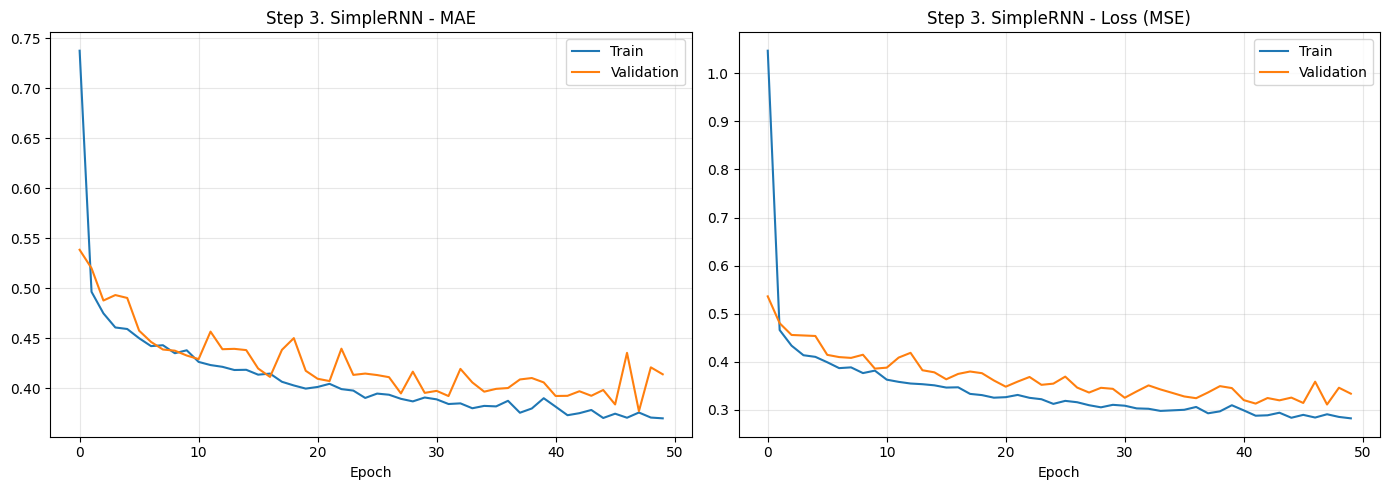

In [86]:
# ============================================
# Step 3. SimpleRNN - 학습 과정 시각화
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_rnn.history['mae'], label='Train')
axes[0].plot(history_rnn.history['val_mae'], label='Validation')
axes[0].set_title('Step 3. SimpleRNN - MAE')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_rnn.history['loss'], label='Train')
axes[1].plot(history_rnn.history['val_loss'], label='Validation')
axes[1].set_title('Step 3. SimpleRNN - Loss (MSE)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Step 4 LSTM 모델 구성

In [87]:
# ============================================
# Step 4. LSTM 모델 구성
# ============================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

model_lstm = Sequential([
    Input(shape=(8, 1)),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_lstm.summary()


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

# Step 4 LSTM - 학습

In [88]:
# ============================================
# Step 4. LSTM - 학습
# ============================================
history_lstm = model_lstm.fit(X_train_rnn, y_train,
                              epochs=50,
                              batch_size=128,
                              validation_split=0.2,
                              verbose=1)


Epoch 1/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.8021 - mae: 0.9798 - val_loss: 0.6738 - val_mae: 0.6208
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6441 - mae: 0.6115 - val_loss: 0.6562 - val_mae: 0.6181
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6371 - mae: 0.6071 - val_loss: 0.6521 - val_mae: 0.5991
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6309 - mae: 0.6023 - val_loss: 0.6390 - val_mae: 0.6071
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6226 - mae: 0.5976 - val_loss: 0.6293 - val_mae: 0.5958
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6164 - mae: 0.5948 - val_loss: 0.6180 - val_mae: 0.5923
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5985 - mae: 0.5826 - val_loss: 0.6121 - val_mae: 0.5903
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5861 - mae: 0.5735 - val_loss: 0.5747 - val_mae: 0.5719
Epoch 9/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - l

# Step 4 LSTM - 테스트 평가

In [89]:
# ============================================
# Step 4. LSTM - 테스트 평가
# ============================================
y_pred_lstm = model_lstm.predict(X_test_rnn).flatten()

mse_lstm = mean_squared_error(y_test, y_pred_lstm)
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
r2_lstm = r2_score(y_test, y_pred_lstm)

print(f"[Step 4] LSTM 결과")
print(f"  MSE    : {mse_lstm:.4f}")
print(f"  MAE    : {mae_lstm:.4f}")
print(f"  R² Score: {r2_lstm:.4f}")


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[Step 4] LSTM 결과
  MSE    : 0.3394
  MAE    : 0.4022
  R² Score: 0.7410


# Step 4 LSTM - 학습 과정 시각화

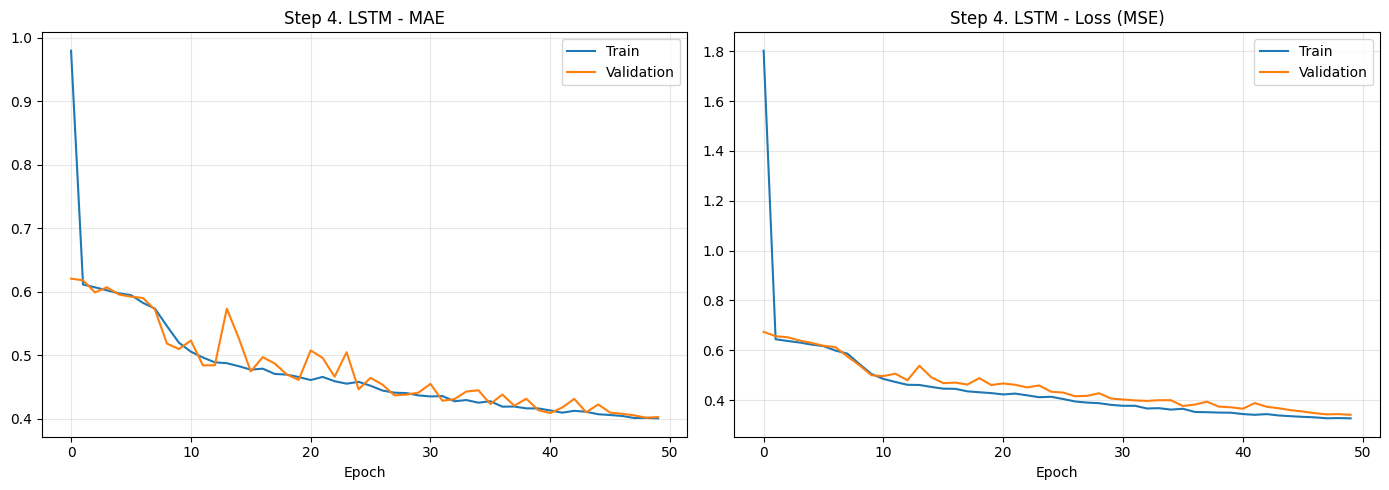

In [90]:
# ============================================
# Step 4. LSTM - 학습 과정 시각화
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_lstm.history['mae'], label='Train')
axes[0].plot(history_lstm.history['val_mae'], label='Validation')
axes[0].set_title('Step 4. LSTM - MAE')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_lstm.history['loss'], label='Train')
axes[1].plot(history_lstm.history['val_loss'], label='Validation')
axes[1].set_title('Step 4. LSTM - Loss (MSE)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Step 5 위도/경도 구간화 (Binning)

In [91]:
# ============================================
# Step 5. 위도/경도 구간화 (Binning)
# ============================================
# 위도(Latitude)와 경도(Longitude)를 구간으로 나눠 정수 인덱스로 변환
# → Embedding 입력으로 사용

n_bins = 50  # 50개 구간으로 나눔

# 위도 구간화 (32~42 범위)
lat_bins = np.linspace(32, 42, n_bins)
lat_train_idx = np.digitize(X_train[:, 6], lat_bins)  # 6번째 컬럼: Latitude
lat_test_idx = np.digitize(X_test[:, 6], lat_bins)

# 경도 구간화 (-124~-114 범위)
lon_bins = np.linspace(-124, -114, n_bins)
lon_train_idx = np.digitize(X_train[:, 7], lon_bins)  # 7번째 컬럼: Longitude
lon_test_idx = np.digitize(X_test[:, 7], lon_bins)

# 나머지 6개 수치 특성 (스케일링된 것 사용)
X_train_num = X_train_scaled[:, :6]
X_test_num = X_test_scaled[:, :6]

print(f"위도 인덱스 범위: {lat_train_idx.min()} ~ {lat_train_idx.max()}")
print(f"경도 인덱스 범위: {lon_train_idx.min()} ~ {lon_train_idx.max()}")
print(f"수치 특성 shape: {X_train_num.shape}")


위도 인덱스 범위: 3 ~ 49
경도 인덱스 범위: 0 ~ 48
수치 특성 shape: (16512, 6)


# Step 5 Embedding + DNN 모델 구성

In [92]:
# ============================================
# Step 5. Embedding + DNN 모델 구성
# ============================================
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate, Dropout

# 입력 1: 위도 (정수 인덱스)
input_lat = Input(shape=(1,), name='latitude')
emb_lat = Embedding(input_dim=n_bins+2, output_dim=8)(input_lat)
emb_lat = Flatten()(emb_lat)

# 입력 2: 경도 (정수 인덱스)
input_lon = Input(shape=(1,), name='longitude')
emb_lon = Embedding(input_dim=n_bins+2, output_dim=8)(input_lon)
emb_lon = Flatten()(emb_lon)

# 입력 3: 나머지 6개 수치 특성
input_num = Input(shape=(6,), name='numeric')

# 3개 입력 합치기
merged = Concatenate()([emb_lat, emb_lon, input_num])
x = Dense(128, activation='relu')(merged)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
output = Dense(1)(x)

model_emb = Model(inputs=[input_lat, input_lon, input_num], outputs=output)
model_emb.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_emb.summary()


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ latitude            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ longitude           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 1, 8)      │        416 │ latitude[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_9         │ (None, 1, 8)      │        416 │ longitude[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 8)         │          0 │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 8)         │          0 │ embedding_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric             │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 22)        │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ flatten_3[0][0],  │
│                     │                   │            │ numeric[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 128)       │      2,944 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 128)       │          0 │ dense_27[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 64)        │      8,256 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 1)         │         65 │ dense_28[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,097 (47.25 KB)

 Trainable params: 12,097 (47.25 KB)

 Non-trainable params: 0 (0.00 B)

# Step 5 Embedding + DNN - 학습

In [93]:
# ============================================
# Step 5. Embedding + DNN - 학습
# ============================================
history_emb = model_emb.fit(
    [lat_train_idx, lon_train_idx, X_train_num], y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50


I0000 00:00:1775025361.210718   20879 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_228206__.14


 85/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.8583 - mae: 1.2669

I0000 00:00:1775025362.775514   20886 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_228206__.14
I0000 00:00:1775025362.798927   20886 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 1.5822 - mae: 0.8469 - val_loss: 0.5443 - val_mae: 0.5300
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5358 - mae: 0.5171 - val_loss: 0.4261 - val_mae: 0.4662
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4676 - mae: 0.4867 - val_loss: 0.3977 - val_mae: 0.4499
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4378 - mae: 0.4718 - val_loss: 0.3868 - val_mae: 0.4397
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4372 - mae: 0.4603 - val_loss: 0.3956 - val_mae: 0.4443
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4117 - mae: 0.4472 - val_loss: 0.3680 - val_mae: 0.4280
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3808 - mae: 0.4351 - val_loss: 0.3475 - val_mae: 0.4164
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3769 - mae: 0.4305 - val_loss: 0.3402 - val_mae: 0.4077
Epoch 9/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3627

# Step 5 Embedding + DNN - 테스트 평가

In [94]:
# ============================================
# Step 5. Embedding + DNN - 테스트 평가
# ============================================
y_pred_emb = model_emb.predict([lat_test_idx, lon_test_idx, X_test_num]).flatten()

mse_emb = mean_squared_error(y_test, y_pred_emb)
mae_emb = mean_absolute_error(y_test, y_pred_emb)
r2_emb = r2_score(y_test, y_pred_emb)

print(f"[Step 5] Embedding + DNN 결과")
print(f"  MSE    : {mse_emb:.4f}")
print(f"  MAE    : {mae_emb:.4f}")
print(f"  R² Score: {r2_emb:.4f}")


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[Step 5] Embedding + DNN 결과
  MSE    : 0.2529
  MAE    : 0.3386
  R² Score: 0.8070


# Step 5 Embedding + DNN - 학습 과정 시각화

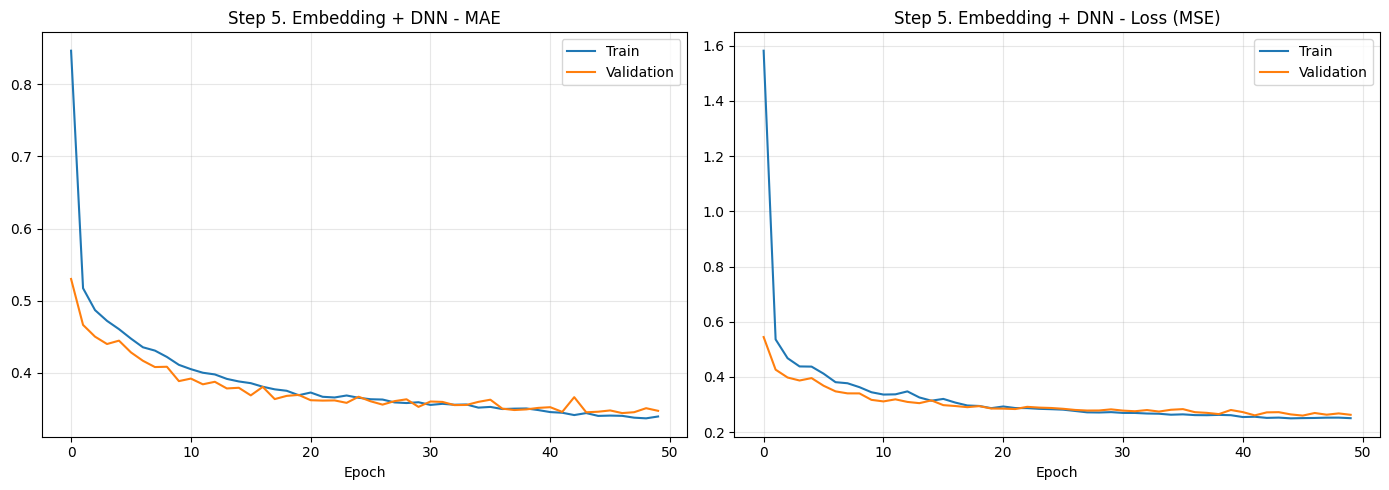

In [95]:
# ============================================
# Step 5. Embedding + DNN - 학습 과정 시각화
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_emb.history['mae'], label='Train')
axes[0].plot(history_emb.history['val_mae'], label='Validation')
axes[0].set_title('Step 5. Embedding + DNN - MAE')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_emb.history['loss'], label='Train')
axes[1].plot(history_emb.history['val_loss'], label='Validation')
axes[1].set_title('Step 5. Embedding + DNN - Loss (MSE)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Step 6 CNN 1D 모델 구성

In [96]:
# ============================================
# Step 6. CNN 1D 모델 구성
# ============================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Input, Dropout

model_cnn = Sequential([
    Input(shape=(8, 1)),
    Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    Conv1D(32, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1)
])

model_cnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_cnn.summary()


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 8, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 8, 32)          │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,753 (57.63 KB)

 Trainable params: 14,753 (57.63 KB)

 Non-trainable params: 0 (0.00 B)

# Step 6 CNN 1D - 학습

In [97]:
# ============================================
# Step 6. CNN 1D - 학습
# ============================================
history_cnn = model_cnn.fit(X_train_rnn, y_train,
                            epochs=50,
                            batch_size=128,
                            validation_split=0.2,
                            verbose=1)


Epoch 1/50


I0000 00:00:1775025515.524007   20885 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_258804__.19
I0000 00:00:1775025516.659440   20885 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775025517.384534   20885 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775025517.641344   88211 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1775025517.673091   20885 dot_search_space.cc:240] All configs were filtered out because non

 95/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7626 - mae: 1.2480

I0000 00:00:1775025519.518363   20889 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_258804__.19


104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2.6547 - mae: 1.2163

I0000 00:00:1775025522.111008   20887 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 1.4914 - mae: 0.8717 - val_loss: 0.6147 - val_mae: 0.5538
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6219 - mae: 0.5695 - val_loss: 0.4927 - val_mae: 0.4931
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5333 - mae: 0.5235 - val_loss: 0.4476 - val_mae: 0.4717
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4991 - mae: 0.5081 - val_loss: 0.4260 - val_mae: 0.4665
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4786 - mae: 0.4930 - val_loss: 0.4398 - val_mae: 0.4937
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4609 - mae: 0.4858 - val_loss: 0.4103 - val_mae: 0.4327
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4377 - mae: 0.4714 - val_loss: 0.3776 - val_mae: 0.4301
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4301 - mae: 0.4682 - val_loss: 0.3811 - val_mae: 0.4470
Epoch 9/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4270

# Step 6 CNN 1D - 테스트 평가

In [98]:
# ============================================
# Step 6. CNN 1D - 테스트 평가
# ============================================
y_pred_cnn = model_cnn.predict(X_test_rnn).flatten()

mse_cnn = mean_squared_error(y_test, y_pred_cnn)
mae_cnn = mean_absolute_error(y_test, y_pred_cnn)
r2_cnn = r2_score(y_test, y_pred_cnn)

print(f"[Step 6] CNN 1D 결과")
print(f"  MSE    : {mse_cnn:.4f}")
print(f"  MAE    : {mae_cnn:.4f}")
print(f"  R² Score: {r2_cnn:.4f}")


129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
[Step 6] CNN 1D 결과
  MSE    : 0.2755
  MAE    : 0.3579
  R² Score: 0.7898


# Step 6 CNN 1D - 학습 과정 시각화

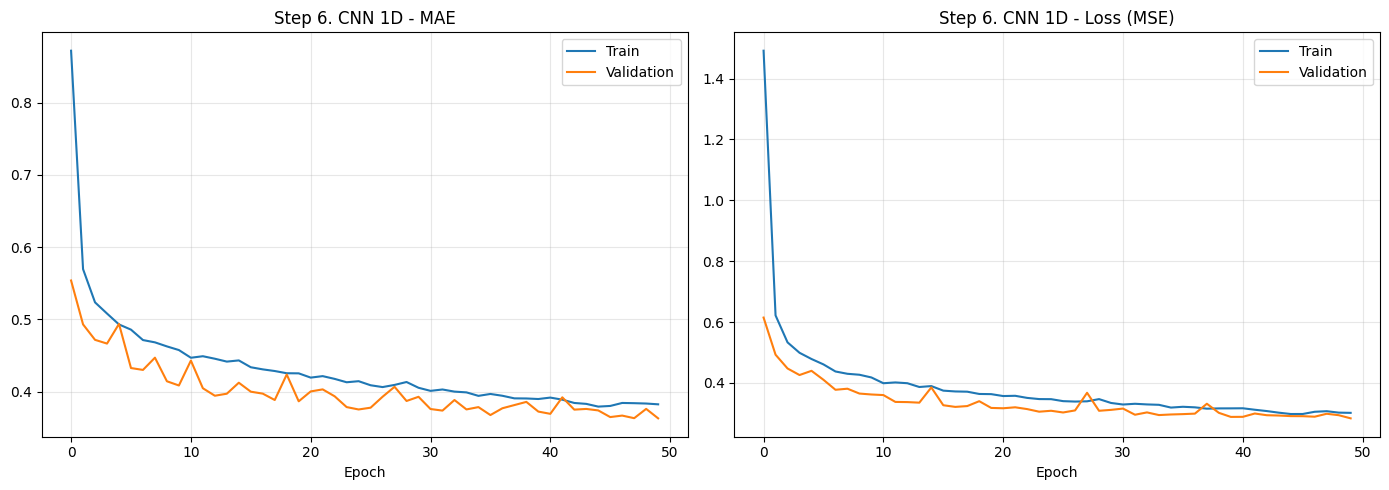

In [99]:
# ============================================
# Step 6. CNN 1D - 학습 과정 시각화
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_cnn.history['mae'], label='Train')
axes[0].plot(history_cnn.history['val_mae'], label='Validation')
axes[0].set_title('Step 6. CNN 1D - MAE')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_cnn.history['loss'], label='Train')
axes[1].plot(history_cnn.history['val_loss'], label='Validation')
axes[1].set_title('Step 6. CNN 1D - Loss (MSE)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Step 7 전체 실험 결과 비교표

In [100]:
# ============================================
# 전체 실험 결과 비교표
# ============================================
import pandas as pd

results = {
    'Step': ['Step 1', 'Step 2', 'Step 3', 'Step 4', 'Step 5', 'Step 6'],
    '모델': ['기본 DNN', 'Deep DNN', 'SimpleRNN', 'LSTM', 'Embedding + DNN', 'CNN 1D'],
    'MSE': [mse_dnn, mse_deep, mse_rnn, mse_lstm, mse_emb, mse_cnn],
    'MAE': [mae_dnn, mae_deep, mae_rnn, mae_lstm, mae_emb, mae_cnn],
    'R² Score': [r2_dnn, r2_deep, r2_rnn, r2_lstm, r2_emb, r2_cnn]
}

df_results = pd.DataFrame(results)
df_results = df_results.set_index('Step')

# 소수점 4자리로 표시
df_results['MSE'] = df_results['MSE'].round(4)
df_results['MAE'] = df_results['MAE'].round(4)
df_results['R² Score'] = df_results['R² Score'].round(4)

df_results


,모델,MSE,MAE,R² Score
Step,,,,
Step 1,기본 DNN,0.2821,0.3590,0.7847
Step 2,Deep DNN,0.3307,0.3845,0.7476
Step 3,SimpleRNN,0.3259,0.4064,0.7513
Step 4,LSTM,0.3394,0.4022,0.7410
Step 5,Embedding + DNN,0.2529,0.3386,0.8070
Step 6,CNN 1D,0.2755,0.3579,0.7898


# 결과 인사이트
① Embedding + DNN이 1위인 이유
위도/경도를 구간화 → 임베딩으로 변환하여 지역 특성을 벡터로 학습
집값은 **위치(지역)**에 가장 크게 영향받기 때문에 위치 임베딩이 효과적
숫자로 넣으면 "위도 37과 38은 비슷"이지만, 임베딩은 지역별 고유 특성 학습

② RNN/LSTM이 낮은 이유
이 데이터는 시계열(시간 순서)이 아닌 테이블 데이터
8개 특성을 억지로 시퀀스로 변환했지만 특성 간 순서에 의미가 없음
RNN/LSTM은 "소득 → 방수 → 인구 → 위치" 순서에서 패턴을 찾으려 했지만 효과 없음

③ Deep DNN이 기본 DNN보다 낮은 이유
데이터 2만 건에 비해 모델이 너무 복잡 (256→128→64→32)
Dropout, BatchNorm이 오히려 학습을 방해 (과소적합)
단순한 구조가 이 데이터에는 더 적합

④ CNN 1D가 준수한 이유
인접 특성 간 국소 패턴을 감지 (예: 방수+침실수, 위도+경도)
시퀀스 순서와 무관하게 근처 특성끼리 묶어서 학습